In [1]:
import wandb
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

In [6]:
api = wandb.Api()

# "entidad/proyecto": normalmente usuario-o-equipo/nombre-del-proyecto
runs = api.runs("volverman22-universidad-aut-noma-de-madrid/gpt2-50M")

rows = []
for run in runs:
    rows.append({
        "id": run.id,
        "nombre": run.name,
        "estado": run.state,
        "val_loss": run.summary.get("validation/loss"),
        **run.config,  # hiperparámetros
    })

df = pd.DataFrame(rows)
df.to_csv("wandb_runs.csv", index=False)

In [7]:
print(df)
# Eliminar por índice
df = df.drop(index=[0, 1, 7, 9, 10, 11, 12, 13, 15, 21])



          id                            nombre    estado  val_loss   seed  \
0   d9zk8yid               earnest-waterfall-3  finished  7.407117    NaN   
1   q7cmkaam                       gpt2-50M-v4  finished  7.407117    NaN   
2   y11sazro                     gpt2-50M-v4.1  finished  7.407117    NaN   
3   hz7reege              gpt2-50M-v4.2_lr_sch   crashed  7.604815    NaN   
4   gzqeqzwb            gpt2-50M-v4.3.2_Xavier  finished  6.602805    NaN   
5   6kr2lnd4            gpt2-50M-v4.3.3_SwiGLU  finished  6.511936    NaN   
6   o80s3ood          gpt2-50M-v4.4_More_depht  finished  6.659394    NaN   
7   z6k13o63          gpt2-50M-v4.5_Looped_Trf  finished       NaN    NaN   
8   tbp5i6gx          gpt2-50M-v4.5_Looped_Trf   crashed  6.497307    NaN   
9   vgqcyyry          gpt2-50M-v4.6_batch_vram  finished  6.765286    NaN   
10  6xhht71p       gpt2-50M-v4.6_batch_vram_32  finished  7.254946    NaN   
11  qdddx721       gpt2-50M-v4.6_batch_vram_32  finished  5.052640    NaN   

In [15]:
print(df)
labels  = df["nombre"]
scores = df["val_loss"]


          id                            nombre    estado  val_loss  seed  \
2   y11sazro                     gpt2-50M-v4.1  finished  7.407117   NaN   
3   hz7reege              gpt2-50M-v4.2_lr_sch   crashed  7.604815   NaN   
4   gzqeqzwb            gpt2-50M-v4.3.2_Xavier  finished  6.602805   NaN   
5   6kr2lnd4            gpt2-50M-v4.3.3_SwiGLU  finished  6.511936   NaN   
6   o80s3ood          gpt2-50M-v4.4_More_depht  finished  6.659394   NaN   
8   tbp5i6gx          gpt2-50M-v4.5_Looped_Trf   crashed  6.497307   NaN   
14  p2cii5sx                gpt2-50M-v4.7-RoPE  finished  5.881263   NaN   
16  kvl9gj01    gpt2-50M-v4.7-learned-batch_2   finished  6.458524   NaN   
17  j5lsmdfg                 v4.8-rope-sp16384  finished  4.879294   NaN   
18  wikie44b           v4.8-rope-gpt_2_tok_gpt  finished  4.905103   NaN   
19  3sd82pzg   v4.8-rope-gpt_2_sp16_more_depth  finished  5.203575   NaN   
20  uv82asb7  v4.8-rope-gpt_2_sp_more_embd_dim  finished  4.527132   NaN   
22  3spmfczc

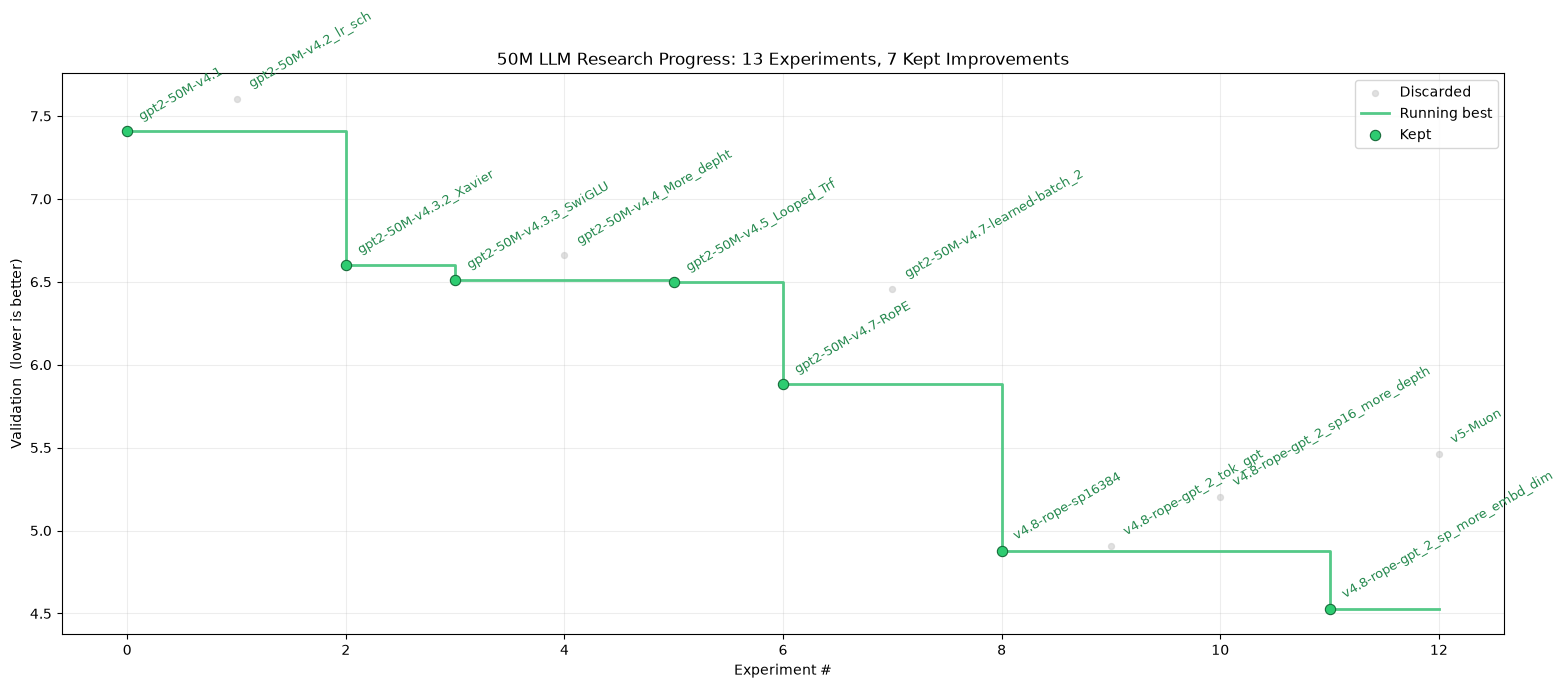

In [26]:




x = np.arange(len(scores))

# Convertir a arrays posicionales para evitar la alineación de índices de pandas
#scores = scores.to_numpy(dtype=float)
labels = labels.reset_index(drop=True)

# Mejor valor observado hasta cada experimento: mínimo acumulado
running_best = np.minimum.accumulate(scores)

# Un experimento se conserva si mejora el mínimo anterior
kept = np.r_[True, scores[1:] < running_best[:-1]]
discarded = ~kept

fig, ax = plt.subplots(figsize=(16, 7))

# Descartados
ax.scatter(
    x[discarded], scores[discarded],
    color="lightgray", s=18, alpha=0.7,
    label="Discarded", zorder=1
)

# Línea del mejor resultado acumulado
ax.step(
    x, running_best,
    where="post", color="#54c987",
    linewidth=2, label="Running best", zorder=2
)

# Mejoras aceptadas
ax.scatter(
    x[kept], scores[kept],
    color="#2ecc71", edgecolor="#176b3a",
    linewidth=0.8, s=55,
    label="Kept", zorder=3
)

# Anotaciones opcionales
for i, text in labels.items():
    ax.annotate(
        text,
        (x[i], scores[i]),
        xytext=(7, 8),
        textcoords="offset points",
        rotation=30,
        fontsize=9,
        color="#278a50"
    )

ax.set_title(f"50M LLM Research Progress: {len(scores)} Experiments, {kept.sum()} Kept Improvements")
ax.set_xlabel("Experiment #")
ax.set_ylabel("Validation  (lower is better)")
ax.grid(True, alpha=0.22)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()